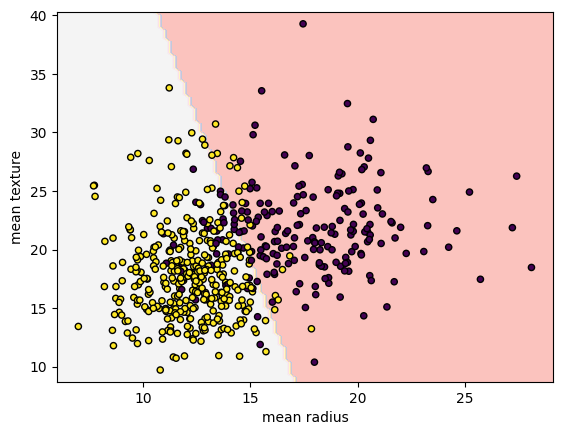

In [5]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

svm = SVC(kernel="linear", C=1)
svm.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        alpha=0.8,
        cmap="Pastel1",
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1],
    )

plt.scatter(X[:, 0], X[:, 1],
            c=y,
            s=20, edgecolors="k")
plt.show()

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.2)

# 2. Convert text to numerical features
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Train SVM classifier
model = SVC(kernel='linear') # Linear kernel is often sufficient for text
model.fit(X_train_tfidf, y_train)

# 4. Predict
predictions = model.predict(X_test_tfidf)


NameError: name 'emails' is not defined

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Placeholder data (replace with your actual email and label data)
emails = [
    "This is a spam email about a lottery win.",
    "Meeting reminder for tomorrow at 10 AM.",
    "You have won a free vacation! Click here.",
    "Project update: tasks completed and next steps.",
    "Urgent: your account has been compromised."
]
labels = [1, 0, 1, 0, 1] # 1 for spam, 0 for not spam

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.2, random_state=42)

# 2. Convert text to numerical features
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Train SVM classifier
model = SVC(kernel='linear') # Linear kernel is often sufficient for text
model.fit(X_train_tfidf, y_train)

# 4. Predict
predictions = model.predict(X_test_tfidf)

print("Predictions:", predictions)
print("True labels:", y_test)

Predictions: [1]
True labels: [0]


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate Synthetic QC Data
np.random.seed(42)
# Normal items (Class 0): Stable sensors
normal_data = np.random.normal(loc=[50, 100, 1.5, 500], scale=[2, 5, 0.2, 10], size=(100, 4))
# Defective items (Class 1): Higher temp, lower pressure, high vibration
defective_data = np.random.normal(loc=[58, 85, 2.5, 510], scale=[3, 8, 0.5, 15], size=(100, 4))

X = np.vstack((normal_data, defective_data))
y = np.concatenate((np.zeros(100), np.ones(100)))

# 2. Preprocessing
# SVM is highly sensitive to feature scales
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Train SVM Model
# 'rbf' kernel is standard for complex sensor relationships
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Pass', 'Fail']))


Confusion Matrix:
[[27  0]
 [ 0 23]]

Classification Report:
              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00        27
        Fail       1.00      1.00      1.00        23

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [13]:
import pandas as pd

data = {
    'animal_name': ['aardvark', 'antelope', 'bass', 'bear', 'boar', 'buffalo', 'calf', 'carp', 'catfish', 'cavy', 'chicken', 'chub', 'clam', 'crab', 'crayfish', 'crow', 'deer', 'dogfish', 'dolphin', 'dove'],
    'hair': [1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'feathers': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    'eggs': [0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    'milk': [1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    'airborne': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    'aquatic': [0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0],
    'predator': [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
    'toothed': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0],
    'backbone': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1],
    'breathes': [1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1],
    'venomous': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'fins': [0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    'legs': [4, 4, 0, 4, 4, 4, 4, 0, 0, 4, 2, 0, 0, 6, 6, 2, 4, 0, 0, 2],
    'tail': [0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
    'domestic': [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    'catsize': [1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    'class_type': [1, 1, 4, 1, 1, 1, 1, 4, 4, 1, 2, 4, 7, 7, 7, 2, 1, 4, 1, 2]
}

pd.DataFrame(data).to_csv('zoo.csv', index=False)
print("zoo.csv created successfully.")


zoo.csv created successfully.


In [14]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load dataset (Example using a local zoo.csv)
data = pd.read_csv("zoo.csv")

# Features: hair, feathers, eggs, milk, airborne, aquatic, predator, etc.
# Target: class_type (1-7 representing animal groups)
X = data.drop(['animal_name', 'class_type'], axis=1)
y = data['class_type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM Model
# Linear kernel is often effective for these high-dimensional binary traits
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

# Predict and Evaluate
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Create Synthetic Dataset (Features: Hair, Feathers, Eggs, Milk, Airborne)
# Rows: [Hair, Feathers, Eggs, Milk, Airborne] (1 = Yes, 0 = No)
data = {
    'hair':      [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    'feathers':  [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0],
    'eggs':      [0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1],
    'milk':      [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    'airborne':  [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0],
    'class':     [0, 0, 1, 1, 0, 1, 1, 2, 0, 1, 1, 2] # 0:Mammal, 1:Bird, 2:Reptile
}

df = pd.DataFrame(data)

# 2. Split Features (X) and Target (y)
X = df.drop('class', axis=1)
y = df['class']

# 3. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Initialize and Train the SVM
# We use a linear kernel because the features are simple binary flags
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# 5. Test the model with a "New" animal
# Sample: [No Hair, No Feathers, Yes Eggs, No Milk, No Airborne] -> Should be Reptile
new_animal = np.array([[0, 0, 1, 0, 0]])
prediction = model.predict(new_animal)

classes = {0: 'Mammal', 1: 'Bird', 2: 'Reptile'}
print(f"Prediction for new animal: {classes[prediction[0]]}")

# 6. Check Overall Accuracy
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100}%")


Prediction for new animal: Reptile
Model Accuracy: 100.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# --- 1. Data Generation (Simulation) ---
# In a real app, you would use `librosa.feature.mfcc()` to extract these from .wav files.
np.random.seed(42)
num_samples = 200       # Simulating 200 songs
num_features = 20       # Simulating 20 MFCC features per song

# X: Feature matrix (200 songs x 20 features)
# We use random floats to mimic normalized MFCC values
X = np.random.rand(num_samples, num_features)

# y: Labels (Genres)
# We randomly assign one of 4 genres to each 'song'
genres = ['Rock', 'Jazz', 'Classical', 'Hip-Hop']
y_raw = np.random.choice(genres, num_samples)

print(f"Generated {num_samples} mock tracks with {num_features} features each.")

# --- 2. Preprocessing ---
# Convert text labels ('Rock', 'Jazz') into numbers (0, 1, 2, 3)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Model Training ---
# K-Nearest Neighbors is a standard baseline for this task
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)
print("Model trained successfully.")

# --- 4. Evaluation ---
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {accuracy * 100:.2f}% (Random data = ~25% expected)")

# --- 5. Prediction on New Data ---
# Simulate a new song's features
new_song_features = np.random.rand(1, num_features)
prediction_index = clf.predict(new_song_features)
predicted_genre = label_encoder.inverse_transform(prediction_index)[0]

print(f"Test Prediction: The new 'song' is classified as: {predicted_genre}")


Generated 200 mock tracks with 20 features each.
Model trained successfully.
Validation Accuracy: 22.50% (Random data = ~25% expected)
Test Prediction: The new 'song' is classified as: Classical


In [12]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Sample Dataset (Feedback and Sentiment Labels)
feedback_data = [
    "The product is amazing and works perfectly!", "Excellent quality, very happy.",    # Positive
    "It's okay, does the job but nothing special.", "Average experience, not great.",  # Neutral
    "Terrible service and the item arrived broken.", "Waste of money, do not buy.",     # Negative
    "Highly recommend to everyone!", "I love this so much!",                          # Positive
    "It is fine, I guess.", "Shipping was a bit slow but product is fine.",            # Neutral
    "Worst purchase ever, very disappointed.", "The app keeps crashing, unusable."     # Negative
]

# Labels: 2 = Positive, 1 = Neutral, 0 = Negative
labels = [2, 2, 1, 1, 0, 0, 2, 2, 1, 1, 0, 0]

# 2. Text Vectorization (Converting words to numbers)
# TF-IDF highlights important words like 'amazing' vs 'broken'
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(feedback_data)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# 4. SVM Model Training
# We use a linear kernel because it is highly efficient for text classification
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

# 5. Testing with New Feedback
test_comments = [
    "It was a decent experience.",
    "I hate how slow the delivery was.",
    "Best investment I have made this year!"
]

# Transform and predict
test_vectors = vectorizer.transform(test_comments)
predictions = svm_model.predict(test_vectors)

# Map numeric predictions back to labels
label_map = {2: "Positive", 1: "Neutral", 0: "Negative"}
for comment, pred in zip(test_comments, predictions):
    print(f"Feedback: '{comment}' -> Result: {label_map[pred]}")


Feedback: 'It was a decent experience.' -> Result: Neutral
Feedback: 'I hate how slow the delivery was.' -> Result: Positive
Feedback: 'Best investment I have made this year!' -> Result: Positive
